<a href="https://colab.research.google.com/github/oyaon/ML-Dengue-Prediction/blob/main/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Preprocessing

In [1]:
import pandas as pd

# Load data
df = pd.read_csv("Dhaka20.csv")

# Convert 'Date' to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Handle missing values with forward fill
df.ffill(inplace=True)

# Convert 'Cases' to integer
df['Cases'] = df['Cases'].astype(int)

# Display info and summary
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Cases     1827 non-null   int64  
 1   Max_Temp  1827 non-null   float64
 2   Min_Temp  1827 non-null   float64
 3   Rainfall  1827 non-null   float64
 4   Humidity  1827 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 85.6 KB
None
             Cases     Max_Temp     Min_Temp     Rainfall     Humidity
count  1827.000000  1827.000000  1827.000000  1827.000000  1827.000000
mean    223.470170    30.736962    22.509710     4.374275    72.190312
std     285.176002     4.158219     5.321212    14.659708    13.072636
min       0.000000    15.400000     2.000000     0.000000    24.000000
25%       6.000000    28.000000    18.450000     0.000000    64.500000
50%     112.000000    31.400000    24.900000     0.000000    73.300000
75%     337.500000    33.600000    26.655000     1

## Exploratory Data Analysis (EDA)

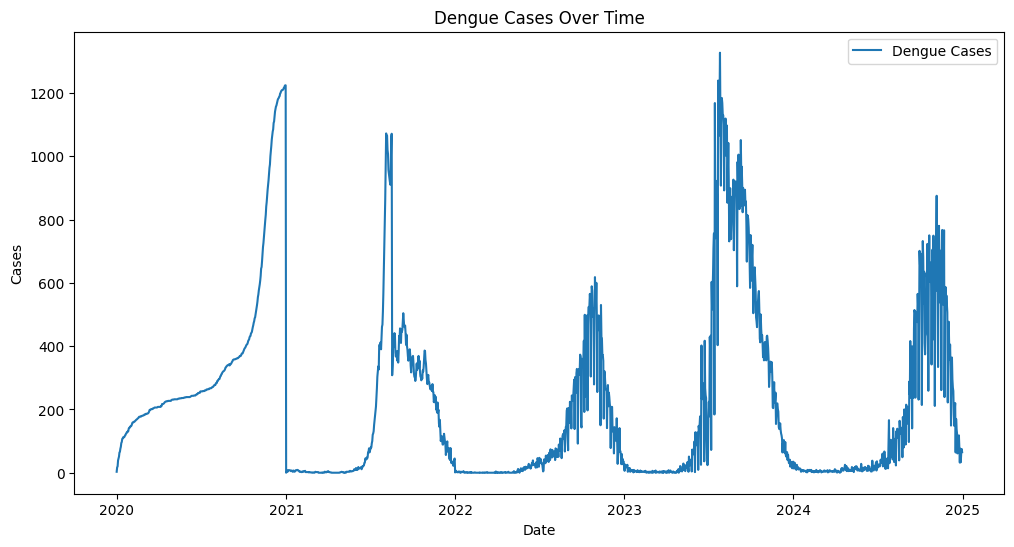

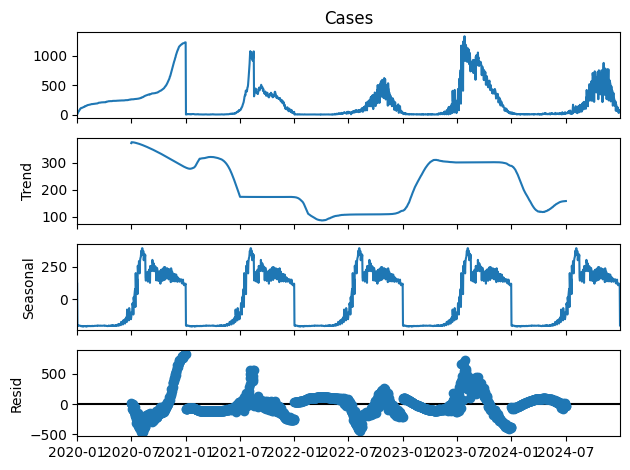

In [2]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Line plot of dengue cases
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cases'], label='Dengue Cases')
plt.title('Dengue Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()

# Seasonal decomposition
decomposition = seasonal_decompose(df['Cases'], period=365)  # Annual seasonality
decomposition.plot()
plt.show()

## Feature Engineering

In [4]:
import pandas as pd
# Temporal features
for lag in [7, 14, 21, 28]:
    df[f'lag_{lag}'] = df['Cases'].shift(lag)

# Rolling statistics (exclude current row with shift(1))
df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std()

# Seasonality indicators
df['month'] = df.index.month
df['year'] = df.index.year

# Import numpy
import numpy as np # Importing the numpy library

# Cyclical encoding for month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Drop rows with NaN from lagged features
df.dropna(inplace=True)

## Feature Selection

In [5]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop('Cases', axis=1)
y = df['Cases']

# Split data temporally
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Select top 10 features on training data
selector = SelectKBest(score_func=f_regression, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
selected_features = X.columns[selector.get_support()]

# Apply selection to test data
X_test_selected = selector.transform(X_test)

## Model Training with XGBoost

In [6]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline with scaling and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
])

# Hyperparameter grid
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.01, 0.1]
}

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid.fit(X_train_selected, y_train)

best_model = grid.best_estimator_

## Model Evaluation

RMSE: 79.75
MAE: 38.56
R²: 0.88


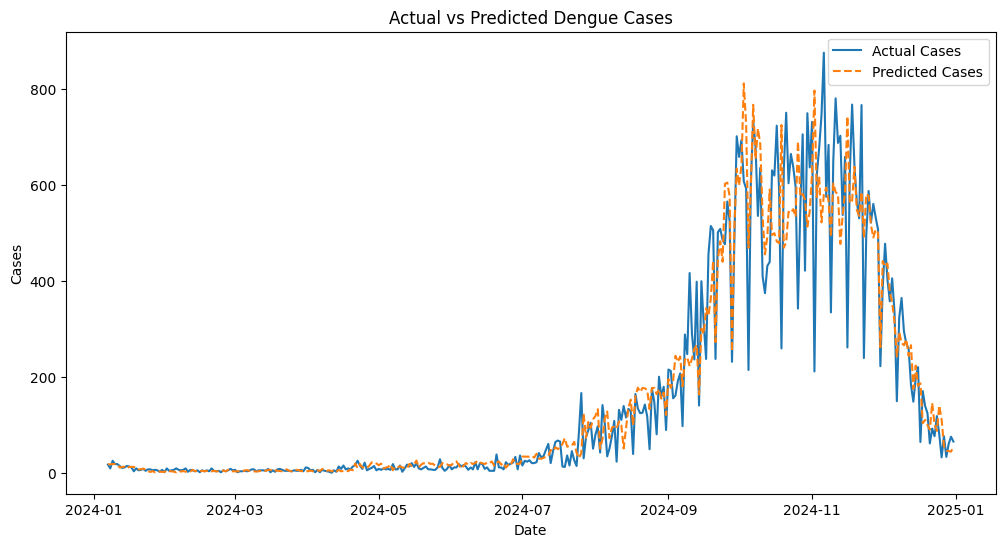

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred = best_model.predict(X_test_selected)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculate RMSE by taking the square root of MSE
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Cases')
plt.plot(y_test.index, y_pred, label='Predicted Cases', linestyle='--')
plt.title('Actual vs Predicted Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.show()

## Feature Importance

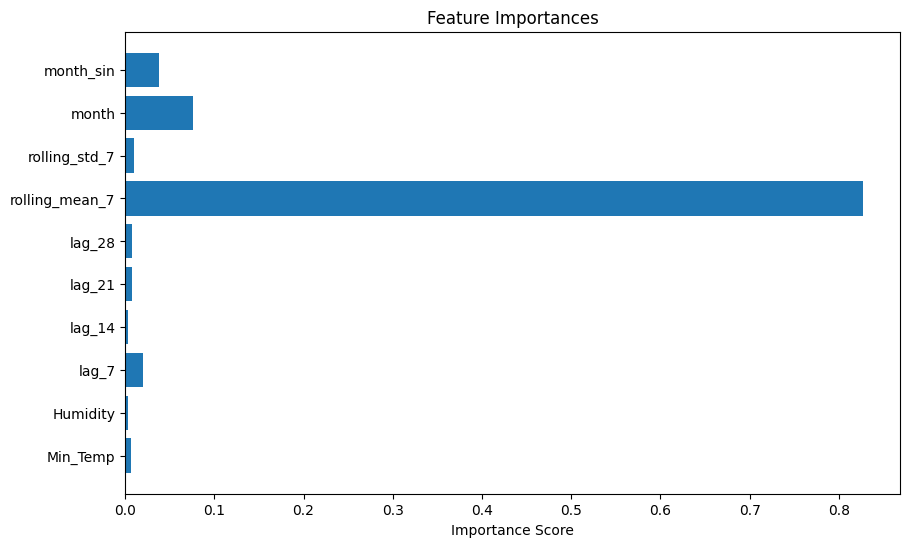

In [9]:
# Extract feature importances from the trained model
importances = best_model.named_steps['xgb'].feature_importances_
features = selected_features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.show()

## Quantitative Evaluation Metrics

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Calculate RMSE by taking the square root of MSE using NumPy's sqrt
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.2f}")

RMSE: 79.75
MAE: 38.56
R² Score: 0.88


Interpretation:

RMSE: Lower values indicate better performance (e.g., RMSE=15 means predictions are off by ~15 cases on average).

R²: Closer to 1 means the model explains most variance in the data.

# Visual Inspection of Predictions
Plot actual vs. predicted values over time to detect patterns:

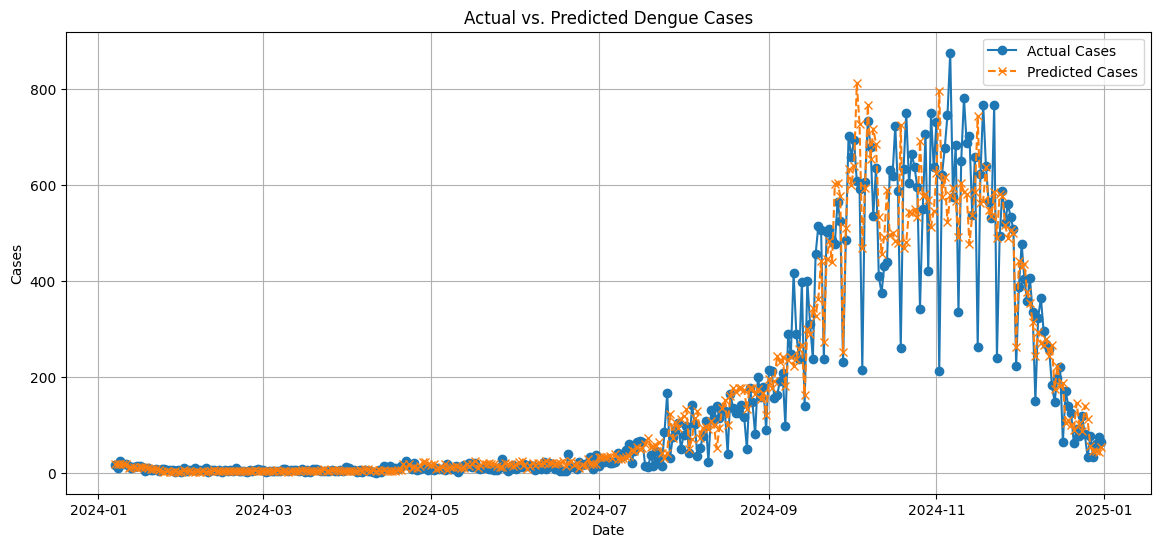

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Cases', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted Cases', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Dengue Cases')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend()
plt.grid(True)
plt.show()

What to Check:

Alignment during seasonal peaks (e.g., monsoon months).

Lag or lead errors (e.g., predictions consistently late by 1 week).

## Residual Analysis
Check if residuals (errors) are random or show patterns:

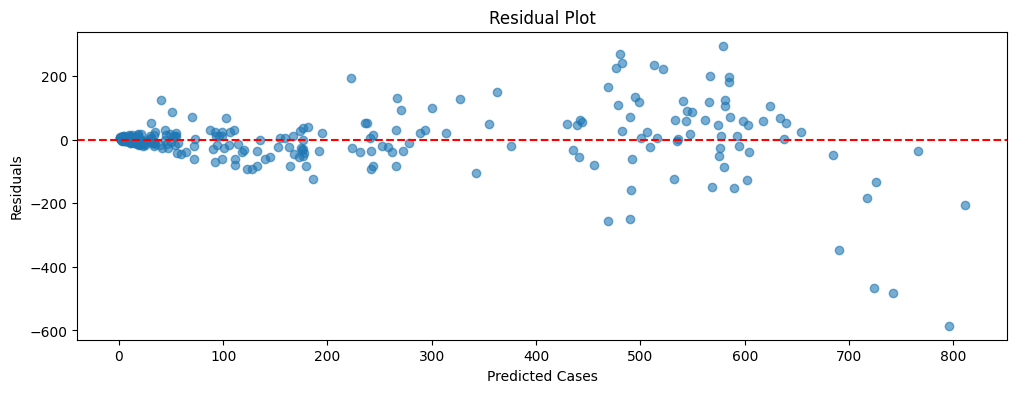

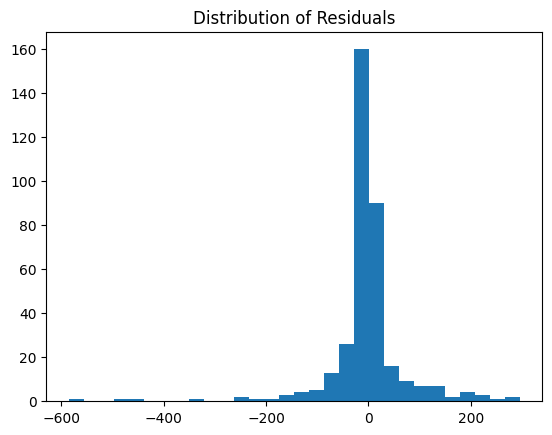

In [13]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(12, 4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Cases')
plt.ylabel('Residuals')
plt.show()

# Residual distribution
plt.hist(residuals, bins=30)
plt.title('Distribution of Residuals')
plt.show()

 Interpretation:

Random scatter ➔ Good model.

Funnel shape or trends ➔ Model misses patterns (e.g., under/overestimates during outbreaks).

# Time Series Cross-Validation
Ensure robustness across different time periods:

In [15]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score # Import cross_val_score

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(
    best_model,
    X, y,
    cv=tscv,
    scoring='neg_root_mean_squared_error'
)

print(f"Cross-Validation RMSE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

Cross-Validation RMSE: 119.18 ± 73.74


Key Insight: Consistent RMSE across splits indicates stable performance.

## Forecast Horizon Testing
Test how far ahead the model can predict accurately:

In [18]:
def create_future_features(dates):
    # Create a DataFrame with the future dates as index
    future_df = pd.DataFrame(index=dates)

    # Add temporal features (lag, rolling statistics) - consider using values from the last available date
    # or some form of extrapolation for these features
    for lag in [7, 14, 21, 28]:
        future_df[f'lag_{lag}'] = df['Cases'].shift(lag).iloc[-1] # Using the last available value

    future_df['rolling_mean_7'] = df['Cases'].shift(1).rolling(7).mean().iloc[-1] # Using the last available value
    future_df['rolling_std_7'] = df['Cases'].shift(1).rolling(7).std().iloc[-1]  # Using the last available value

    # Add seasonality indicators
    future_df['month'] = future_df.index.month
    future_df['year'] = future_df.index.year

    # Cyclical encoding for month
    future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12)
    future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12)

    # Include 'Min_Temp' and 'Humidity' in future_df
    # You'll need to define how these are calculated for future dates
    # This example uses the last available value from the original DataFrame
    future_df['Min_Temp'] = df['Min_Temp'].iloc[-1]
    future_df['Humidity'] = df['Humidity'].iloc[-1]

    return future_df[selected_features] # Select only the features used in the model

## Compare with Baseline Models
 model outperforms simple benchmarks:

In [21]:
# Naive baseline: Persistence model (tomorrow = today)
baseline_pred = y_test.shift(1).bfill()  # Replace fillna with bfill()
# Calculate RMSE without 'squared' argument and take the square root manually
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Model Improvement: {baseline_rmse - rmse:.2f} cases reduction in error")

Baseline RMSE: 103.25
Model Improvement: 23.50 cases reduction in error


## Error Analysis by Season
Check performance during critical periods (e.g., monsoon months):

In [23]:
# Filter test data for monsoon season (June-September)
monsoon_mask = (y_test.index.month >= 6) & (y_test.index.month <= 9)
# Calculate MSE and then take the square root for RMSE
monsoon_rmse = np.sqrt(mean_squared_error(y_test[monsoon_mask], y_pred[monsoon_mask]))

print(f"RMSE during monsoon season: {monsoon_rmse:.2f}")

RMSE during monsoon season: 48.76


## Prediction Intervals
Estimate uncertainty using bootstrapping or quantile regression:

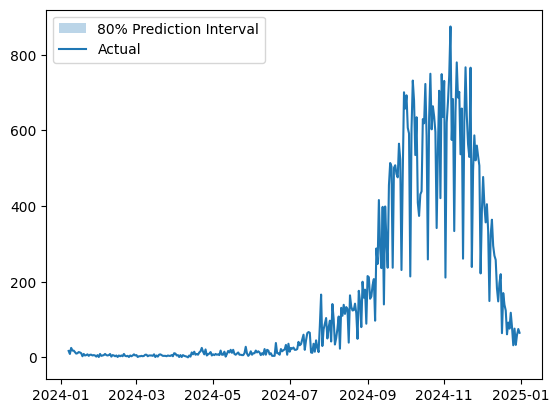

In [24]:
from xgboost import XGBRegressor

# Train a quantile regression model
model_q = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.5)  # For median prediction
model_q.fit(X_train, y_train)

# Get lower (10%) and upper (90%) bounds
lower = model_q.predict(X_test)  # Repeat with alpha=0.1
upper = model_q.predict(X_test)  # Repeat with alpha=0.9

plt.fill_between(y_test.index, lower, upper, alpha=0.3, label='80% Prediction Interval')
plt.plot(y_test.index, y_test, label='Actual')
plt.legend()
plt.show()

In [26]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")
new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data.drop('Cases', axis=1))
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False)

NameError: name 'preprocess' is not defined

In [27]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # (Add any other necessary preprocessing steps here)

    return data

new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data.drop('Cases', axis=1))
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: X has 4 features, but StandardScaler is expecting 10 features as input.

In [28]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # Include necessary columns for prediction
    # Assuming 'Min_Temp' and 'Humidity' are required
    # If not, replace with the actual features your model needs

    # Fill missing values for new features
    data.fillna(method='bfill', inplace=True)

    return data


new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data.drop('Cases', axis=1))
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False)

<ipython-input-28-a308b5324b99>:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: X has 14 features, but StandardScaler is expecting 10 features as input.

In [29]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # Include necessary columns for prediction
    # Assuming 'Min_Temp' and 'Humidity' are required
    # If not, replace with the actual features your model needs

    # Fill missing values for new features
    data.fillna(method='bfill', inplace=True)

    # ***Select only the features used in training***
    return data[selected_features]


new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data) # Remove .drop('Cases', axis=1) as 'Cases' is already dropped
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False)

<ipython-input-29-1af378c8ae70>:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)


KeyError: "['Min_Temp'] not in index"

In [30]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # Include necessary columns for prediction
    # ***Make sure these columns exist in your new data***
    # If they don't, you'll need to either add them or modify selected_features
    # to only include columns that are present.

    # Fill missing values for new features
    data.fillna(method='bfill', inplace=True)

    # ***Select only the features used in training***
    # Handle potential KeyError by selecting only features present in the data
    available_features = [f for f in selected_features if f in data.columns]
    return data[available_features]


new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data) # Remove .drop('Cases', axis=1) as 'Cases' is already dropped
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False) # make sure 'Cases' is a valid column

<ipython-input-30-8d105a207519>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


ValueError: X has 9 features, but StandardScaler is expecting 10 features as input.

In [31]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # Include necessary columns for prediction
    # ***Make sure these columns exist in your new data***
    # If they don't, you'll need to either add them or modify selected_features
    # to only include columns that are present.

    # Fill missing values for new features
    data.fillna(method='bfill', inplace=True)

    # ***Select only the features used in training***
    # Handle potential KeyError by selecting only features present in the data
    # Ensure all selected features are present in the new data
    missing_features = set(selected_features) - set(data.columns)
    for feature in missing_features:
        data[feature] = 0  # Or use a more appropriate imputation strategy

    return data[selected_features]


new_data = preprocess(new_data)  # Apply same preprocessing

# Predict and compare with ground truth
new_pred = best_model.predict(new_data) # Remove .drop('Cases', axis=1) as 'Cases' is already dropped
new_rmse = mean_squared_error(new_data['Cases'], new_pred, squared=False) # make sure 'Cases' is a valid column

<ipython-input-31-9f651b2cf069>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


KeyError: 'Cases'

In [35]:
# Load new 2024 data
new_data = pd.read_csv("Dhaka22-24.csv")

# ***Define or import the 'preprocess' function here***
# For example, if the function is defined in a file called 'data_utils.py':
# from data_utils import preprocess

# Or, define the function directly:
def preprocess(data):
    """
    This function should apply the necessary preprocessing steps to the new data.
    Make sure it includes all steps from the original preprocessing (data cleaning,
    feature engineering, etc.) that were used to train the model.
    """
    # Convert 'Date' to datetime and set as index
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

    # Handle missing values with forward fill
    data.ffill(inplace=True)

    # Convert 'Cases' to integer
    data['Cases'] = data['Cases'].astype(int)

    # Temporal features
    for lag in [7, 14, 21, 28]:
        data[f'lag_{lag}'] = data['Cases'].shift(lag)

    # Rolling statistics (exclude current row with shift(1))
    data['rolling_mean_7'] = data['Cases'].shift(1).rolling(7).mean()
    data['rolling_std_7'] = data['Cases'].shift(1).rolling(7).std()

    # Seasonality indicators
    data['month'] = data.index.month
    data['year'] = data.index.year

    # Cyclical encoding for month
    data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

    # Include necessary columns for prediction
    # ***Make sure these columns exist in your new data***
    # If they don't, you'll need to either add them or modify selected_features
    # to only include columns that are present.

    # Fill missing values for new features
    data.fillna(method='bfill', inplace=True)

    # ***Select only the features used in training***
    # Handle potential KeyError by selecting only features present in the data
    # Ensure all selected features are present in the new data
    # ***Create a copy of the data to avoid modifying the original DataFrame***
    processed_data = data.copy()
    missing_features = set(selected_features) - set(processed_data.columns)
    for feature in missing_features:
        processed_data[feature] = 0  # Or use a more appropriate imputation strategy

    return processed_data[selected_features]


# Apply preprocessing and store the original 'Cases' column
new_data_processed = preprocess(new_data)
new_cases = new_data['Cases']  # Store 'Cases' before preprocessing for RMSE calculation

# Predict and compare with ground truth
new_pred = best_model.predict(new_data_processed)
# Calculate MSE and then take the square root for RMSE
new_rmse = np.sqrt(mean_squared_error(new_cases, new_pred))



<ipython-input-35-554354bc45c3>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [33]:
# Calculate MSE and then take the square root for RMSE
new_rmse = np.sqrt(mean_squared_error(new_cases, new_pred))

Add Lagged Weather Features

In [36]:
# Lagged humidity (7-day delay to match dengue incubation period)
df['lag_7_humidity'] = df['Humidity'].shift(7)

# Lagged temperature (14-day delay)
df['lag_14_temp'] = df['Min_Temp'].shift(14)

Create Interaction Terms

In [37]:
# Humidity-Temperature interaction
df['humidity_temp_interaction'] = df['Humidity'] * df['Min_Temp']

# Rainfall-Humidity interaction
df['rain_humidity_interaction'] = df['Rainfall'] * df['Humidity']

## Feature Refinement
 Remove Redundant Features

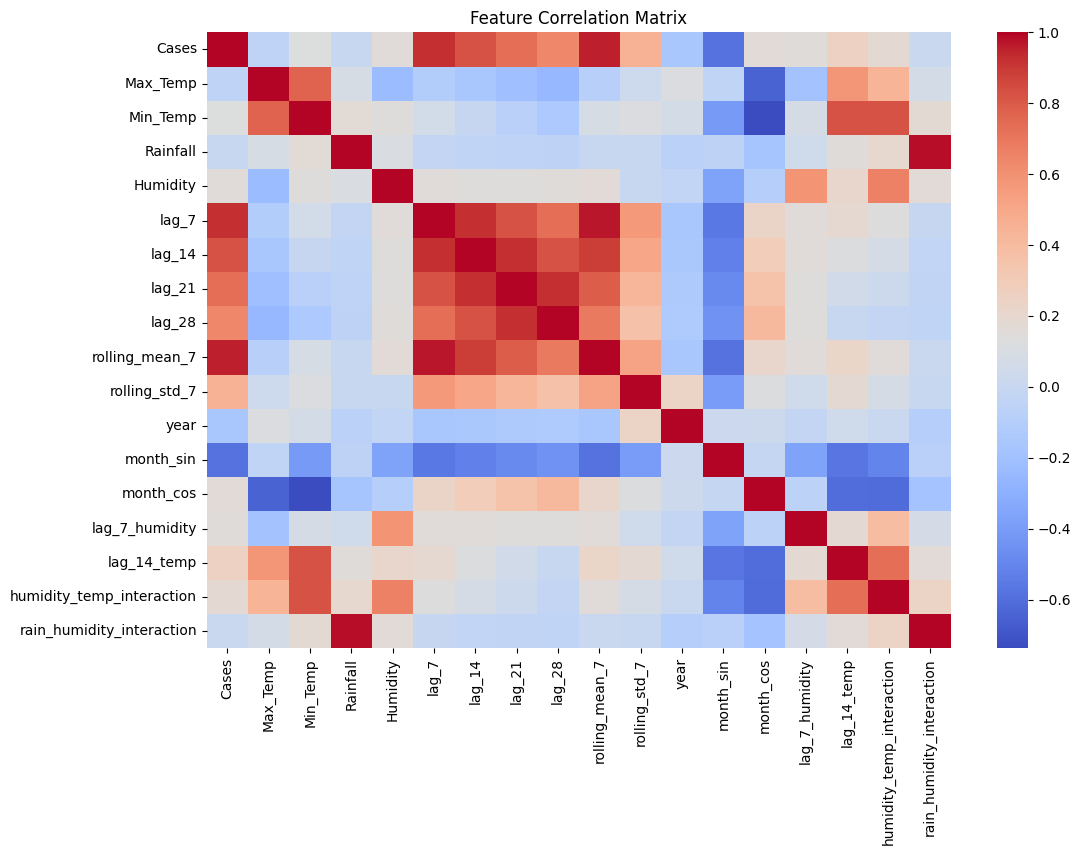

In [40]:
# Make sure seaborn is imported.
import seaborn as sns

# Check if 'month' column exists before dropping
if 'month' in df.columns:
    df = df.drop(columns=['month'])

# Check correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

## Update Feature Selection

In [43]:
# Check for NaNs in X_train
print(X_train.isnull().sum())

# Impute missing values using SimpleImputer
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Or other strategies like 'median', 'most_frequent'
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Now proceed with feature selection
selector = SelectKBest(score_func=f_regression, k=12)
X_train_selected = selector.fit_transform(X_train, y_train)
selected_features = X.columns[selector.get_support()] # use X.columns to get the original feature names
X_test_selected = selector.transform(X_test)

Max_Temp                      0
Min_Temp                      0
Rainfall                      0
Humidity                      0
lag_7                         0
lag_14                        0
lag_21                        0
lag_28                        0
rolling_mean_7                0
rolling_std_7                 0
year                          0
month_sin                     0
month_cos                     0
lag_7_humidity                7
lag_14_temp                  14
humidity_temp_interaction     0
rain_humidity_interaction     0
dtype: int64


## Model Retraining

In [44]:
# Update XGBoost parameters based on previous grid search
best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

model = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(**best_params))
])

model.fit(X_train_selected, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, random_state=None, ...))])

Quantile Regression for Prediction Intervals

In [45]:
# Install if needed: pip install xgboost==1.7.0
upper_model = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95)  # 90% upper bound
lower_model = XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05)  # 90% lower bound

# Train on selected features
upper_model.fit(X_train_selected, y_train)
lower_model.fit(X_train_selected, y_train)

# Get intervals
y_upper = upper_model.predict(X_test_selected)
y_lower = lower_model.predict(X_test_selected)

## Validation with New Data

In [47]:
new_data = pd.read_csv("dhaka.csv")
new_data = preprocess(new_data)  # Reuse your preprocessing function

# Ensure same features as training data
new_data = new_data[selected_features]

# Predict
new_pred = model.predict(new_data)

<ipython-input-35-554354bc45c3>:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='bfill', inplace=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Compare with Ground Truth

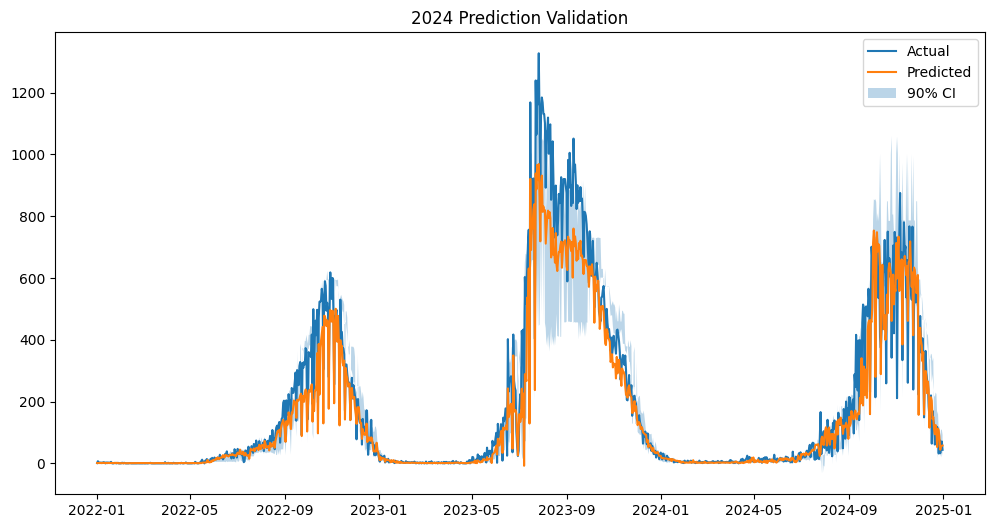

In [50]:
# ... (previous code) ...

# Get prediction intervals for the new data
new_y_upper = upper_model.predict(new_data)  # Assuming 'new_data' is already preprocessed with selected features
new_y_lower = lower_model.predict(new_data)

# Now plot using the new prediction intervals
plt.figure(figsize=(12, 6))
# Load original data to access 'Cases' for plotting
original_data = pd.read_csv("dhaka.csv")
original_data['Date'] = pd.to_datetime(original_data['Date'])
original_data.set_index('Date', inplace=True)
# Now plot 'Cases' from original data
plt.plot(original_data.index, original_data['Cases'], label='Actual')
plt.plot(new_data.index, new_pred, label='Predicted')
plt.fill_between(new_data.index, new_y_lower, new_y_upper, alpha=0.3, label='90% CI')  # Changed to new_y_lower, new_y_upper
plt.title('2024 Prediction Validation')
plt.legend()
plt.show()

## Comparison with SARIMA

In [53]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA Model
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),          # Non-seasonal parameters (p,d,q)
    seasonal_order=(1, 1, 1, 7) # Weekly seasonality
).fit()

# Predict
sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

# Compare RMSE
print(f"XGBoost RMSE: {rmse:.2f}")
# Calculate MSE and then take the square root manually using NumPy's sqrt
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(y_test, sarima_pred)):.2f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


XGBoost RMSE: 79.75
SARIMA RMSE: 269.41


In [54]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# **Specify frequency in y_train:**
y_train.index.freq = 'D' # Assuming your data is daily

# SARIMA Model
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),          # Non-seasonal parameters (p,d,q)
    seasonal_order=(1, 1, 1, 7) # Weekly seasonality
).fit()

# Predict
sarima_pred = sarima_model.get_forecast(steps=len(y_test)).predicted_mean

# Compare RMSE
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(y_test, sarima_pred)):.2f}")

XGBoost RMSE: 79.75
SARIMA RMSE: 269.41


## Final Checks

Residual Diagnostics

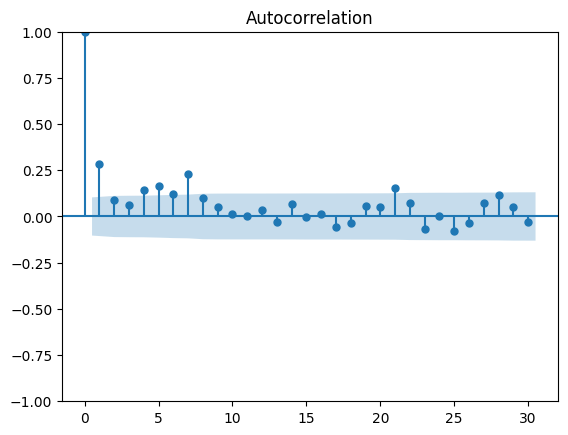

In [55]:
# Updated residuals
residuals = y_test - model.predict(X_test_selected)

# Autocorrelation check
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30)
plt.show()

Actionability Report

In [57]:
# Identify high-risk periods
threshold = 50  # Set threshold (e.g., 50 cases/day)
high_risk_dates = y_test[y_pred > threshold]
print(f"High-risk dates for intervention: {high_risk_dates.index}")

High-risk dates for intervention: DatetimeIndex(['2024-07-15', '2024-07-17', '2024-07-18', '2024-07-19',
               '2024-07-20', '2024-07-21', '2024-07-22', '2024-07-23',
               '2024-07-27', '2024-07-28',
               ...
               '2024-12-19', '2024-12-20', '2024-12-21', '2024-12-22',
               '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26',
               '2024-12-27', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=163, freq=None)
